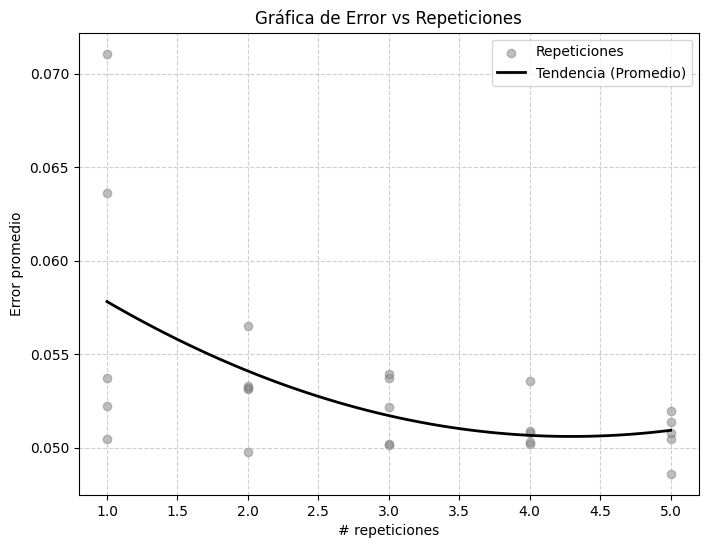

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Datos de ejemplo
# 5 valores de X (repeticiones)
x_puntos = np.array([1, 2, 3, 4, 5]) 

# 5 valores de Y para cada X (simulando los puntos apilados del dibujo)
y_puntos = np.array([
    [0.06361293, 0.05373593, 0.0522309, 0.0710694, 0.05047208],
    [0.04974844, 0.0531534, 0.05649732, 0.05332925, 0.05318239],
    [0.0501752, 0.05019602, 0.05395847, 0.05373445, 0.0521862],
    [0.05088575, 0.0507737, 0.05355119, 0.05031118, 0.05022671],
    [0.05196576, 0.04861313, 0.0513648, 0.05046624, 0.05077649]
])

# 2. Preparar los datos para la línea de tendencia (promedios)
x_promedios = x_puntos
y_promedios = np.mean(y_puntos, axis=1)

# 3. Definir una función para la curva (ajuste exponencial simple: y = a * e^(-b*x))
def modelo_cuadratico(x, a, b, c):
    return a * x**2 + b * x + c

# Ajustar la curva a los promedios
popt, _ = curve_fit(modelo_cuadratico, x_promedios, y_promedios)

# 4. Crear la gráfica
plt.figure(figsize=(8, 6))

# Dibujar los puntos "apilados"
for i in range(len(x_puntos)):
    plt.scatter([x_puntos[i]] * 5, y_puntos[i], color='gray', alpha=0.5, label='Repeticiones' if i == 0 else "")

# Dibujar la línea de tendencia suave
x_curva = np.linspace(1, 5, 100)
plt.plot(x_curva, modelo_cuadratico(x_curva, *popt), color='black', linewidth=2, label='Tendencia (Promedio)')

# Configuración de etiquetas (basado en tu dibujo)
plt.xlabel('# repeticiones')
plt.ylabel('Error promedio')
plt.title('Gráfica de Error vs Repeticiones')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()